# (09) OOD: MNIST -> ImgNet

host = ```any```, device = ```cuda:0```

**Motivation**:  <br>


In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: mach

## Setup

In [3]:
from base.helper import filter_boundaries
from utils.animation import animate_recons


anim_dir = pjoin(tmp_dir, 'animations/ood')
os.makedirs(anim_dir, exist_ok=True)

print(sorted(os.listdir(anim_dir)))

[
    'MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta-15.mp4',
    'MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta-4.0.mp4',
    'MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta-4.0_FULL.mp4',
    'MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta=2.0.mp4',
    'MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta=4.0.mp4'
]

## Load model (MNIST)

In [4]:
from analysis.final import get_list_of_fits

patterns = ['MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)', 'fwd-(3,7)']
fits, root = get_list_of_fits(patterns)
print(fits)

[
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(3,7)_recon-mse_chewie-0_(2025_09_08,18:47)',
    'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(3,7)_recon-mse_dtheta-15_yoru-0_(2025_09_08,2
2:25)'
]

In [5]:
fit = 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(3,7)_recon-mse_chewie-0_(2025_09_08,18:47)'
# fit = 'poisson_<ngd|lin>_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(3,7)_recon-mse_dtheta-15_yoru-0_(2025_09_08,22:25)'
tr, meta = load_model_lite(pjoin(root, fit), device=device)
meta['checkpoint']

100

### sanity check

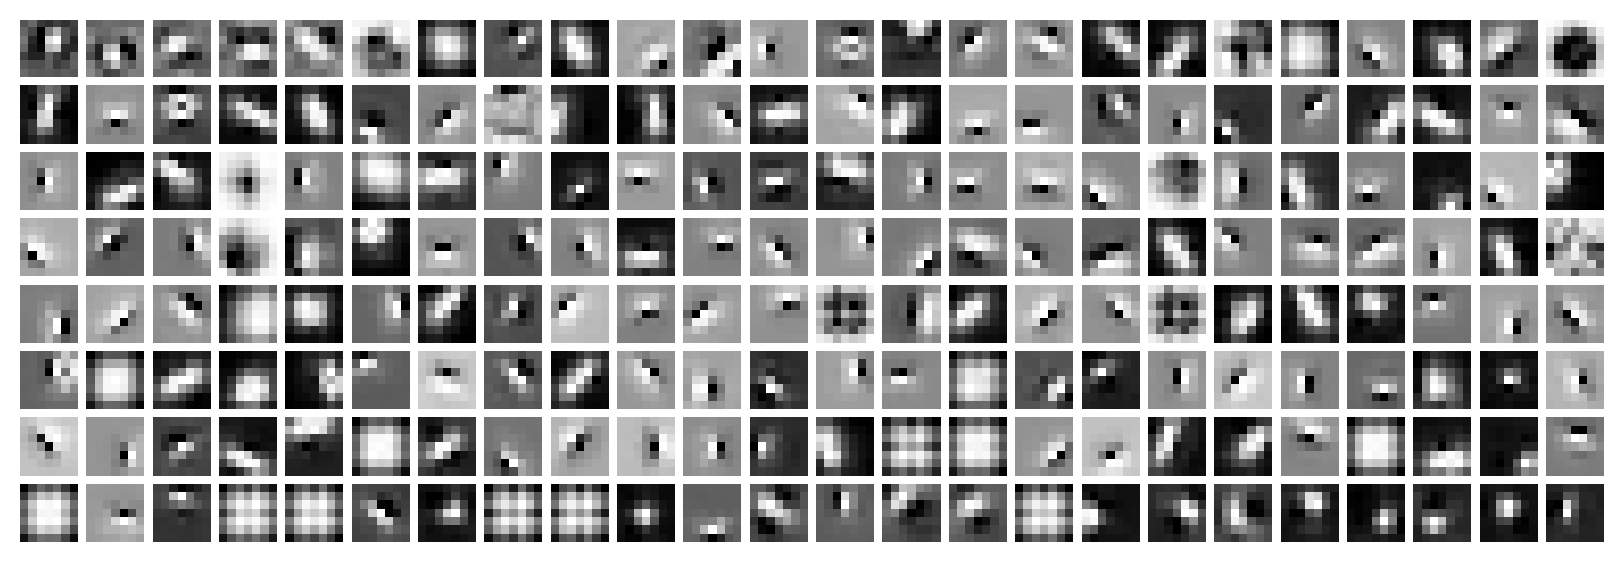

In [6]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0));

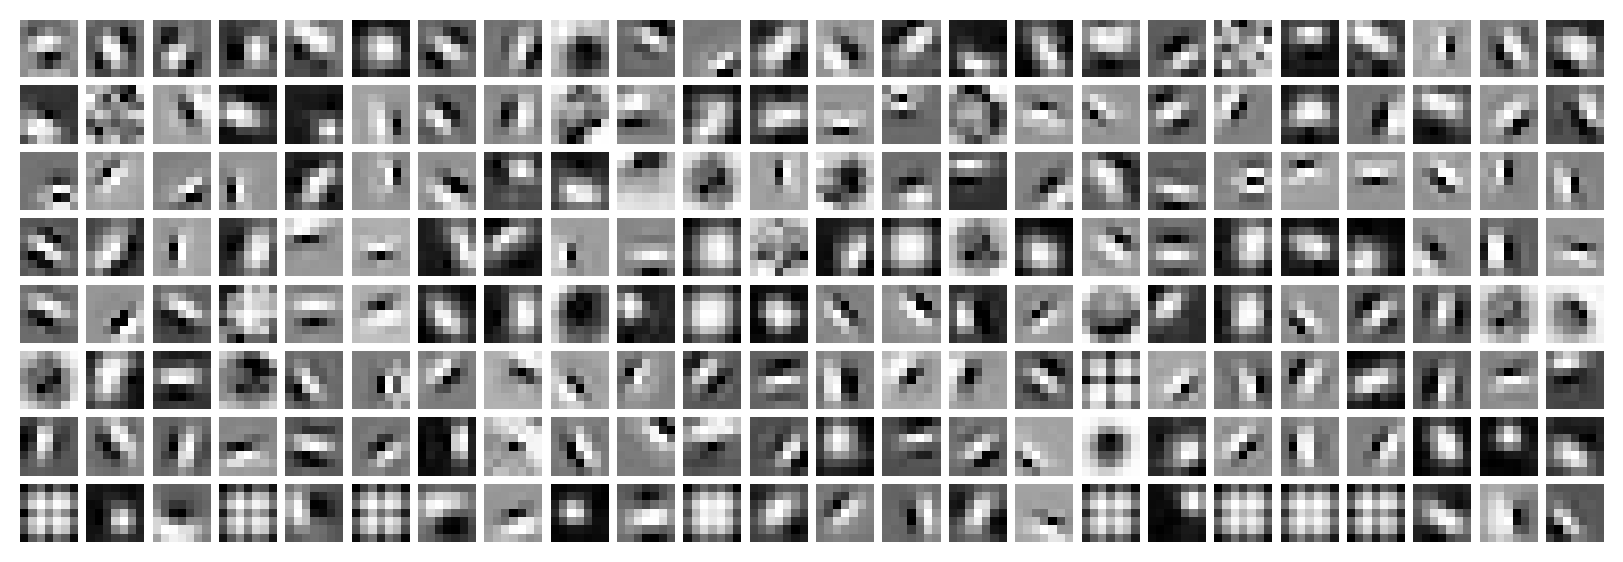

In [6]:
## Was: the other model dtheta=15

In [7]:
dt_str = '\n'.join([
    f"dt_enc = {tr.model.layer.log_dt_enc[0].exp().item():0.3f}",
    f"dt_fwd = {tr.model.layer.log_dt_fwd[0].exp().item():0.3f}",
])
print(dt_str)

dt_enc = 0.426
dt_fwd = 1.909

100%|███████████████████████████████████| 2/2 [00:59<00:00, 29.88s/it]


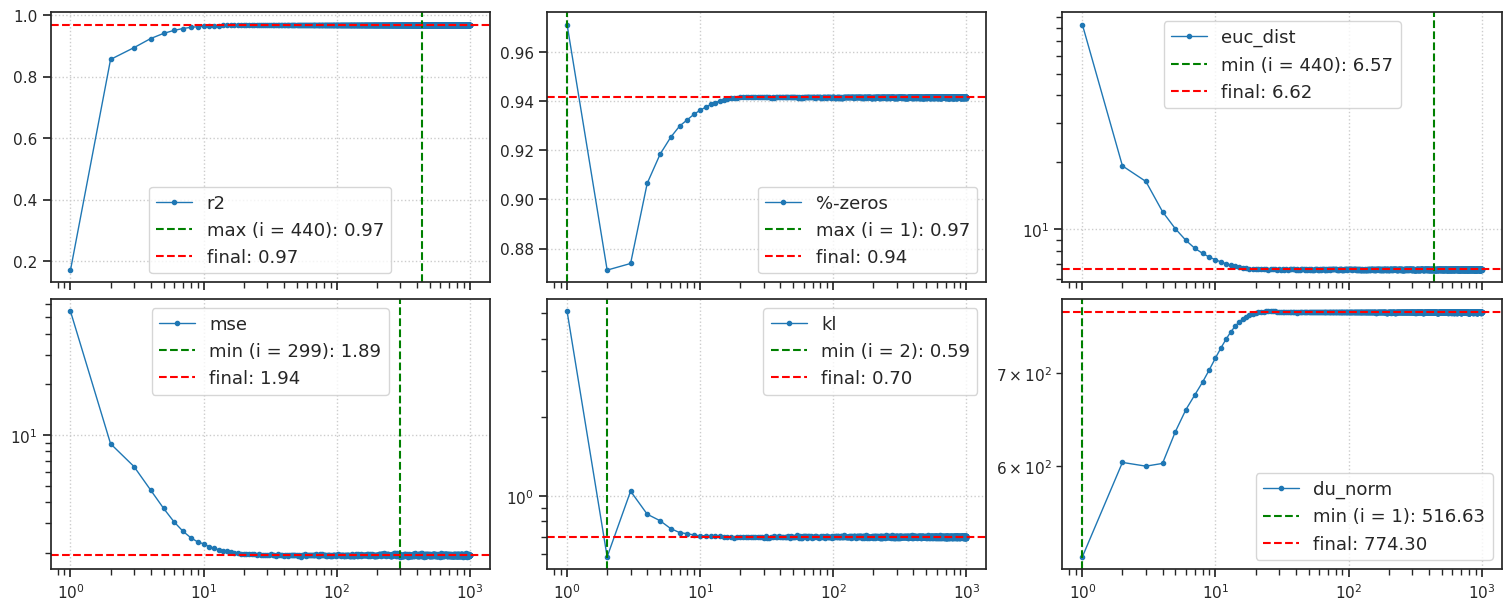

CPU times: user 1min, sys: 97.7 ms, total: 1min
Wall time: 1min


In [8]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=2)
_ = plot_convergence(results=results, color='C0')

## prepare ImageNet data

### compute mnist variance mask

In [6]:
sigma = tr.data_dependent_init(
    t_total=300,
    n_data_batches=5,
    data_batch_sz=2_000,
    dry_run=True,
    verbose=True,
)

100%|███████████████████████████████████| 5/5 [00:12<00:00,  2.46s/it]


In [7]:
var_mnist = tonp(torch.square(sigma.squeeze()))
mask_mnist = var_mnist / np.max(var_mnist)

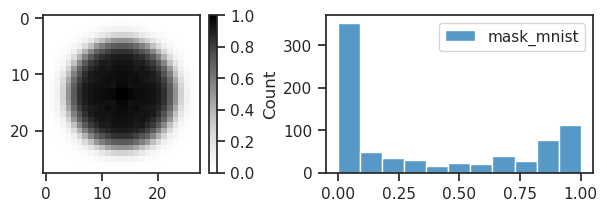

In [8]:
fig, axes = create_figure(1, 2, (6, 2), width_ratios=[1, 1.5])

im = axes[0].imshow(mask_mnist, cmap='Greys')
plt.colorbar(im, ax=axes[0])

sns.histplot(mask_mnist.ravel(), label='mask_mnist', ax=axes[1])
axes[1].legend()

plt.show()

### get imgnet dataloader

In [9]:
_, vld, tst = make_dataset('ImageNet32', device=device, skip_trn=True)

In [10]:
x = vld[0]
x_shift_scaled = (x + 1.0) / 2.0

x_shift_scaled.shape

torch.Size([50000, 3, 32, 32])

In [11]:
# x: [N, 3, 32, 32], values in [-1, 1]
weights = torch.tensor(
    [0.299, 0.587, 0.114],
    device=x.device,
    dtype=x.dtype,
).view(1, 3, 1, 1)

# Rescale to [0, 1], grayscale
# w/ BT.601 luma, keep channel dim
x_gray = torch.sum(
    x_shift_scaled * weights,
    dim=1,
    keepdim=True,
)

# Optional, guard against tiny numeric drift
x_gray = x_gray.clamp(0, 1)
x_gray.shape

torch.Size([50000, 1, 32, 32])

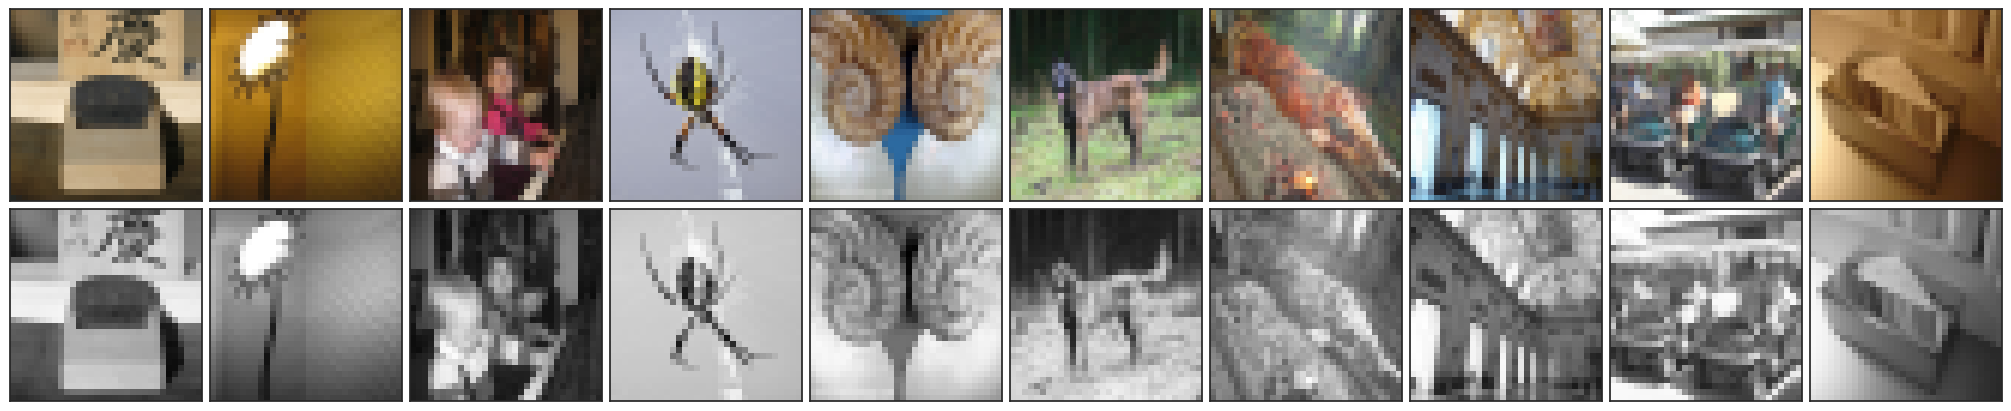

In [12]:
nrows, ncols = 2, 10
fig, axes = create_figure(nrows, ncols, (2 * ncols, 2 * nrows), 'all', 'all')

for i in range(ncols):
    x2p = np.transpose(tonp(x_shift_scaled[i]), (1, 2, 0))
    axes[0, i].imshow(x2p)
    
    x2p = tonp(x_gray[i].squeeze())
    axes[1, i].imshow(x2p, cmap='Greys_r', vmin=0, vmax=1)

remove_ticks(axes, False)
plt.show()

In [13]:
x_gray_cropped = x_gray[:, :, 2:30, 2:30]

mask = torch.tensor(
    mask_mnist,
    device=x_gray_cropped.device,
    dtype=x_gray_cropped.dtype,
).unsqueeze(0).unsqueeze(0)
x_gray_cropped_masked = x_gray_cropped * mask

x_gray_cropped_masked.shape

torch.Size([50000, 1, 28, 28])

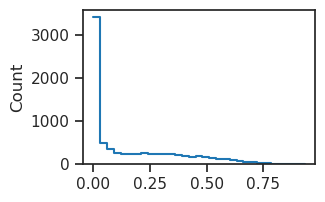

In [14]:
histplot(x_gray_cropped_masked[:10].ravel());

### get feeder imgnet

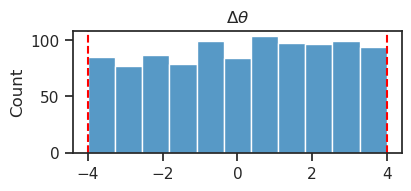

In [15]:
feeder_imgnet = tr.feeder_vld.fork(
    reinit=True,
    x=x_gray_cropped_masked,
    y=vld[1],
    shuffle=False,
    drop_last=False,
    batch_size=1_000,
)
d_thetas = feeder_imgnet.apply_anneal(-1)

fig, ax = create_figure(1, 1, (4, 1.8))
sns.histplot(tonp(d_thetas), ax=ax)
ax.axvline(-feeder_imgnet.max_delta_theta, color='r', ls='--')
ax.axvline(feeder_imgnet.max_delta_theta, color='r', ls='--')
ax.set_title(r"$\Delta \theta$")
plt.show()

100%|███████████████████████████████████| 2/2 [00:57<00:00, 28.73s/it]


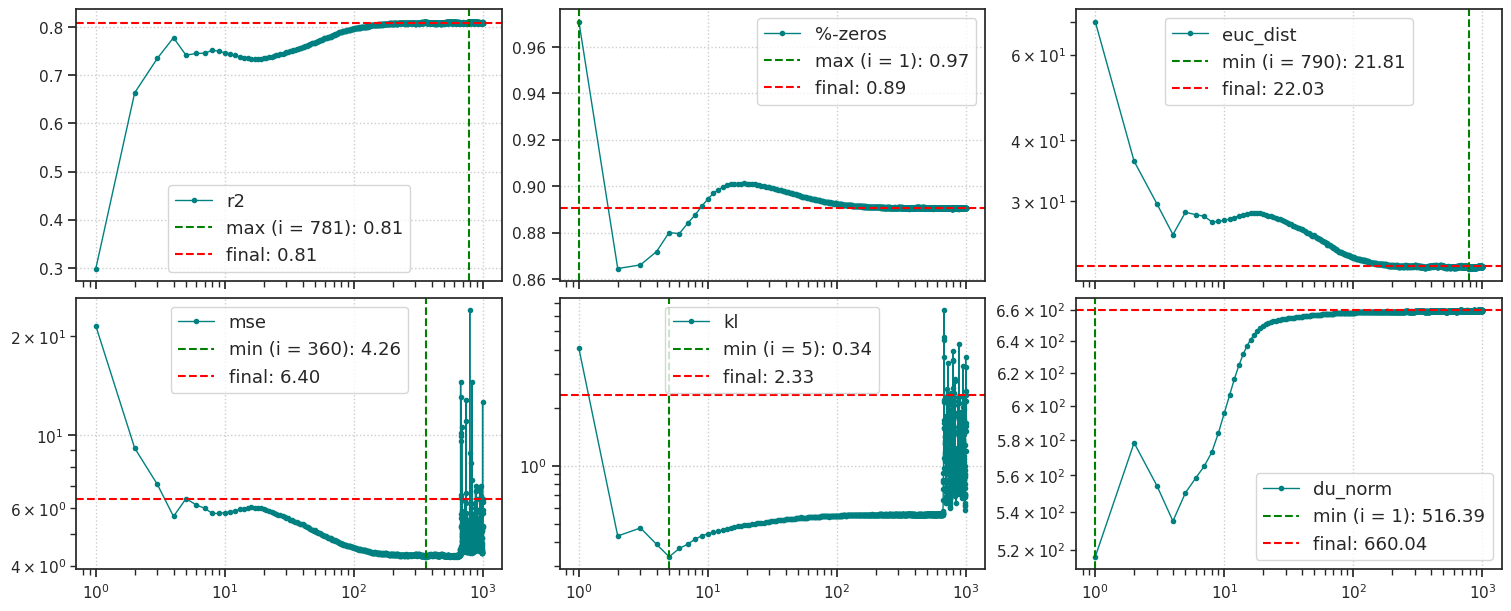

CPU times: user 56.9 s, sys: 346 ms, total: 57.3 s
Wall time: 58.9 s


In [16]:
%%time

results = tr.analysis(feeder_imgnet, t_total=1000, n_data_batches=2)
_ = plot_convergence(results=results, color='teal')

100%|█████████████████████████████████| 50/50 [06:07<00:00,  7.35s/it]


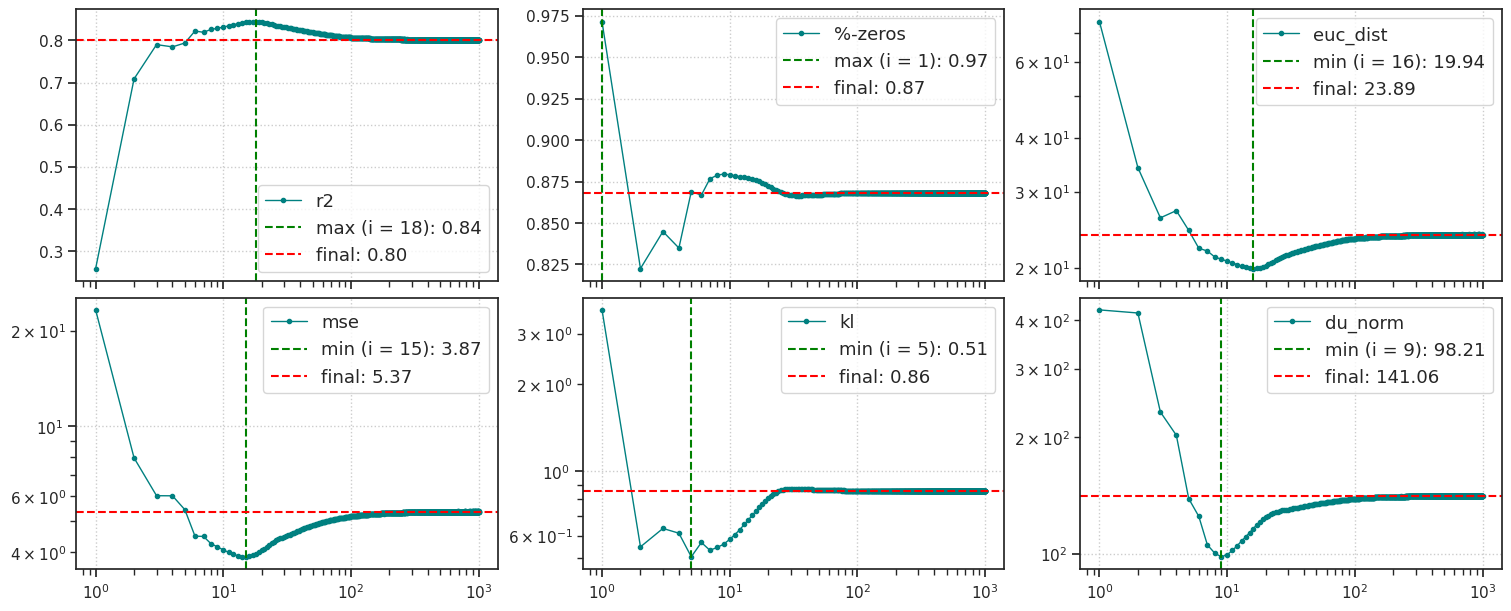

CPU times: user 6min 7s, sys: 1.4 s, total: 6min 8s
Wall time: 6min 8s


In [21]:
## Was: the other model dtheta=15

### xtract imgnet features

In [17]:
%%time


output = tr.xtract_ftr(
    data=feeder_imgnet,
    t_total=1000,
    save_freq=1,
    data_batch_sz=64,
    n_data_batches=1,
    return_state=False,
    return_recon=True,
    verbose=False,
)
list(output)

CPU times: user 52.4 s, sys: 1min 8s, total: 2min
Wall time: 2min 1s


['r2', 'mse', 'du_norm_0', 'samples', 'recon', 'true', 'times']

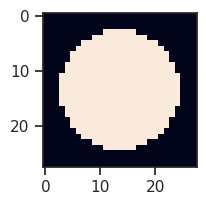

In [20]:
mask_thres = 0.2
imshow(mask_mnist > mask_thres);

In [21]:
sample_ids = range(12)

true_to_anim = output['true'][sample_ids]
recon_to_anim = output['recon'][sample_ids]

true_to_anim, recon_to_anim = filter_boundaries(
    [true_to_anim, recon_to_anim],
    mask=mask_mnist > mask_thres,
)

true_to_anim.shape, recon_to_anim.shape

((12, 1000, 1, 22, 22), (12, 1000, 1, 22, 22))

CPU times: user 4min 43s, sys: 8.63 s, total: 4min 52s
Wall time: 5min 21s


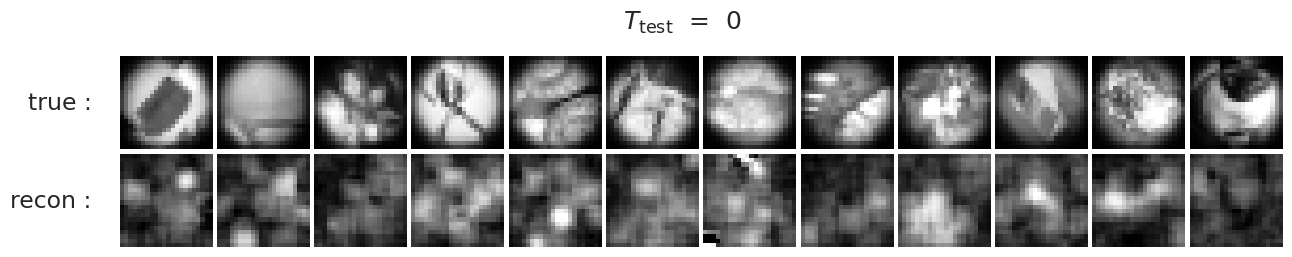

In [23]:
%%time


file_name = '_'.join([
    f"{tr.model.cfg.dataset}-to-ImageNet32",
    tr.model.cfg.str_kms,
    tr.model.cfg.str_fwd,
    f"dtheta-{tr.model.cfg.feeder_cfg['max_delta_theta']}",
])

_ = animate_recons(
    save_file=pjoin(anim_dir, f"{file_name}.mp4"),
    recon=recon_to_anim,
    true=true_to_anim,
    n_samples=12,
    vmin=0.0,
    vmax=0.75,
    # dry_run=True,
)

## Below was with the other model

the one with dtheta = 15.0

### get feeder imgnet with custom dtheta and sampling

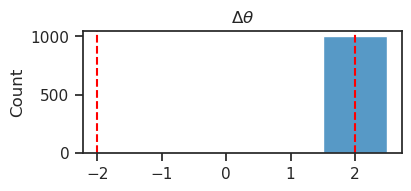

In [34]:
feeder_imgnet = tr.feeder_vld.fork(
    reinit=True,
    x=x_gray_cropped_masked,
    y=vld[1],
    shuffle=False,
    drop_last=False,
    batch_size=1_000,
    max_delta_theta=2.0,
    sample_uniform=False,
)
d_thetas = feeder_imgnet.apply_anneal(-1)

fig, ax = create_figure(1, 1, (4, 1.8))
sns.histplot(tonp(d_thetas), ax=ax)
ax.axvline(-feeder_imgnet.max_delta_theta, color='r', ls='--')
ax.axvline(feeder_imgnet.max_delta_theta, color='r', ls='--')
ax.set_title(r"$\Delta \theta$")
plt.show()

100%|█████████████████████████████████| 50/50 [06:05<00:00,  7.31s/it]


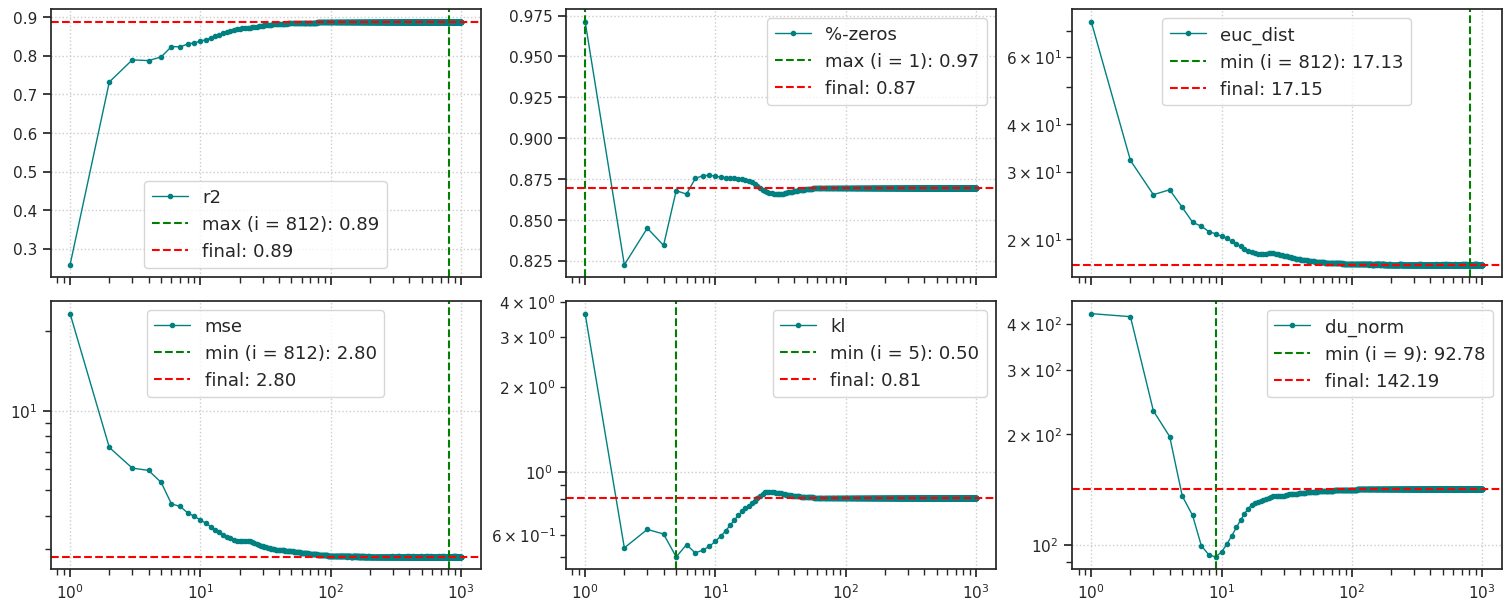

CPU times: user 6min 6s, sys: 231 ms, total: 6min 6s
Wall time: 6min 6s


In [45]:
%%time

results = tr.analysis(feeder_imgnet, t_total=1000, n_data_batches=-1)
_ = plot_convergence(results=results, color='teal')

100%|█████████████████████████████████| 50/50 [06:07<00:00,  7.35s/it]


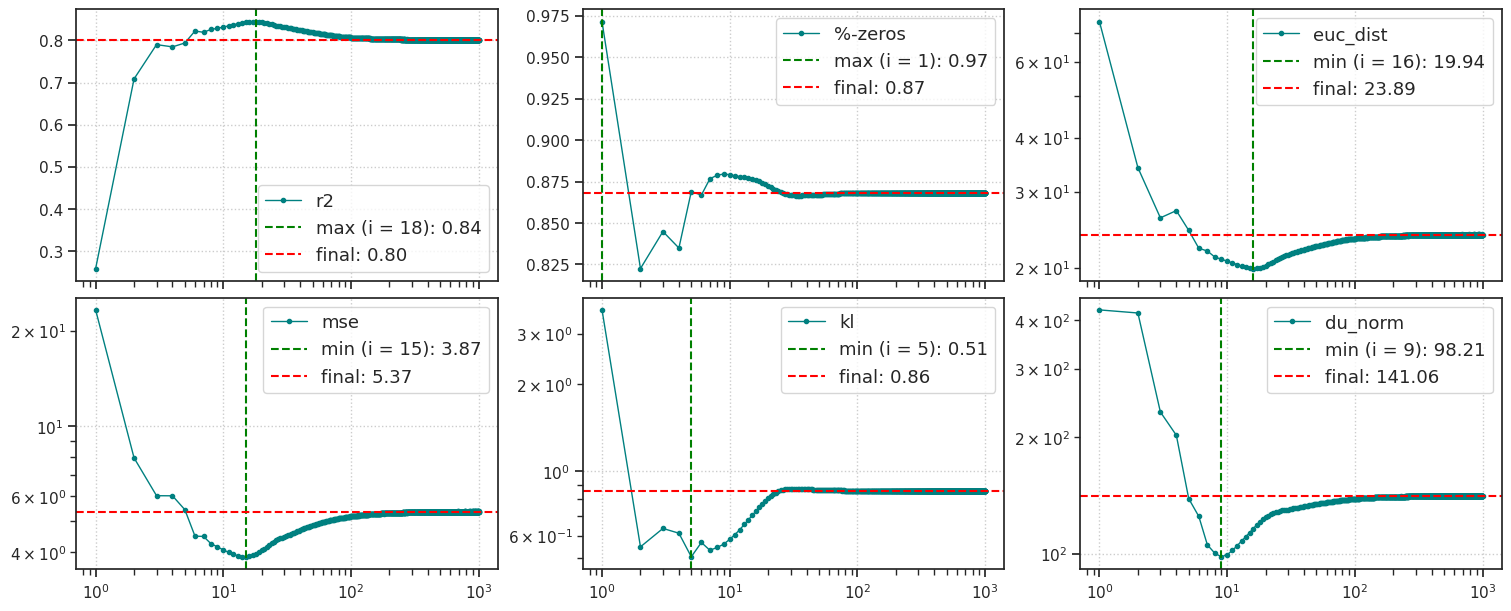

CPU times: user 6min 7s, sys: 1.4 s, total: 6min 8s
Wall time: 6min 8s


In [21]:
## Was: dtheta sampled from [-15, 15]

### xtract imgnet features

In [36]:
%%time


output = tr.xtract_ftr(
    data=feeder_imgnet,
    t_total=1000,
    save_freq=1,
    data_batch_sz=64,
    n_data_batches=1,
    return_state=False,
    return_recon=True,
    verbose=False,
)
list(output)

CPU times: user 16.2 s, sys: 14.7 s, total: 30.9 s
Wall time: 31 s


['r2', 'mse', 'du_norm_0', 'samples', 'recon', 'true', 'times']

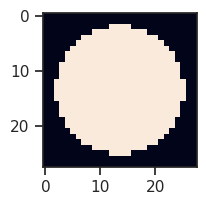

In [37]:
imshow(mask_mnist > 0.1);

In [38]:
sample_ids = range(12)

true_to_anim = output['true'][sample_ids]
recon_to_anim = output['recon'][sample_ids]

true_to_anim, recon_to_anim = filter_boundaries(
    [true_to_anim, recon_to_anim],
    mask=mask_mnist > 0.1,
)

true_to_anim.shape, recon_to_anim.shape

((12, 1000, 1, 24, 24), (12, 1000, 1, 24, 24))

In [43]:
mp4_file_name = '_'.join([
    f"{tr.model.cfg.dataset}-to-ImageNet32",
    tr.model.cfg.str_kms,
    tr.model.cfg.str_fwd,
    f"dtheta={feeder_imgnet.max_delta_theta:0.1f}",
])
mp4_file_name = f"{mp4_file_name}.mp4"

print(mp4_file_name)

MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta=2.0.mp4

CPU times: user 2min 17s, sys: 4.03 s, total: 2min 21s
Wall time: 2min 25s


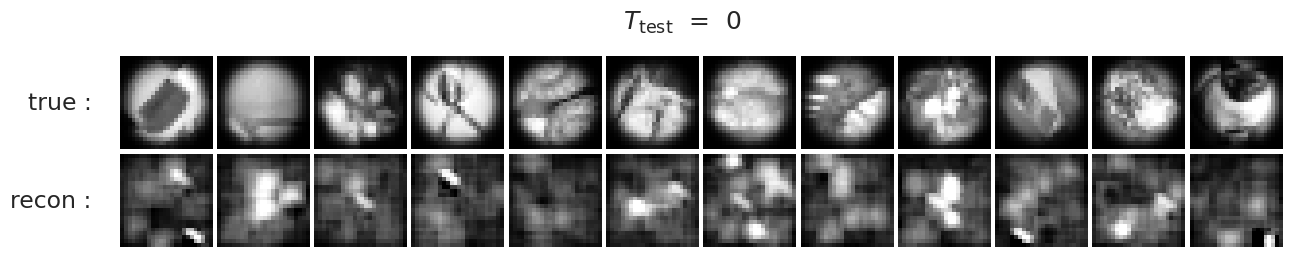

In [44]:
%%time


_ = animate_recons(
    save_file=pjoin(anim_dir, mp4_file_name),
    recon=recon_to_anim,
    true=true_to_anim,
    n_samples=12,
    vmin=0.0,
    vmax=0.75,
    # dry_run=True,
)

### what about dtheta = 4.0

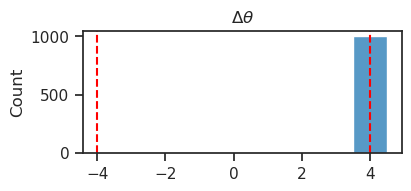

In [46]:
feeder_imgnet = tr.feeder_vld.fork(
    reinit=True,
    x=x_gray_cropped_masked,
    y=vld[1],
    shuffle=False,
    drop_last=False,
    batch_size=1_000,
    max_delta_theta=4.0,
    sample_uniform=False,
)
d_thetas = feeder_imgnet.apply_anneal(-1)

fig, ax = create_figure(1, 1, (4, 1.8))
sns.histplot(tonp(d_thetas), ax=ax)
ax.axvline(-feeder_imgnet.max_delta_theta, color='r', ls='--')
ax.axvline(feeder_imgnet.max_delta_theta, color='r', ls='--')
ax.set_title(r"$\Delta \theta$")
plt.show()

100%|███████████████████████████████████| 3/3 [00:21<00:00,  7.17s/it]


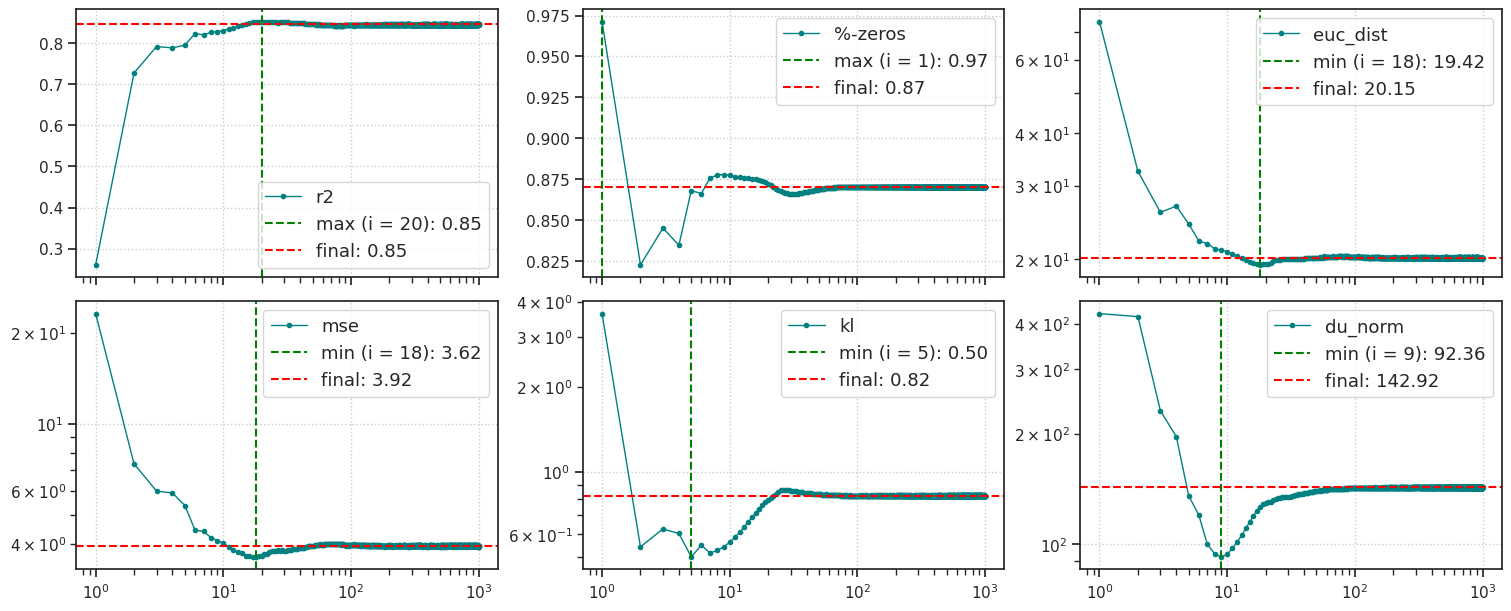

CPU times: user 22.7 s, sys: 27.6 ms, total: 22.7 s
Wall time: 22.7 s


In [47]:
%%time

results = tr.analysis(feeder_imgnet, t_total=1000, n_data_batches=3)
_ = plot_convergence(results=results, color='teal')

In [48]:
%%time


output = tr.xtract_ftr(
    data=feeder_imgnet,
    t_total=1000,
    save_freq=1,
    data_batch_sz=64,
    n_data_batches=1,
    return_state=False,
    return_recon=True,
    verbose=False,
)


sample_ids = range(12)

true_to_anim = output['true'][sample_ids]
recon_to_anim = output['recon'][sample_ids]

true_to_anim, recon_to_anim = filter_boundaries(
    [true_to_anim, recon_to_anim],
    mask=mask_mnist > 0.1,
)

true_to_anim.shape, recon_to_anim.shape

CPU times: user 16 s, sys: 13.8 s, total: 29.8 s
Wall time: 29.8 s


((12, 1000, 1, 24, 24), (12, 1000, 1, 24, 24))

In [49]:
mp4_file_name = '_'.join([
    f"{tr.model.cfg.dataset}-to-ImageNet32",
    tr.model.cfg.str_kms,
    tr.model.cfg.str_fwd,
    f"dtheta={feeder_imgnet.max_delta_theta:0.1f}",
])
mp4_file_name = f"{mp4_file_name}.mp4"

print(mp4_file_name)

MNIST+rotate-to-ImageNet32_kms-(192,8,3)_fwd-(3,7)_dtheta=4.0.mp4

CPU times: user 2min 17s, sys: 3.98 s, total: 2min 21s
Wall time: 2min 25s


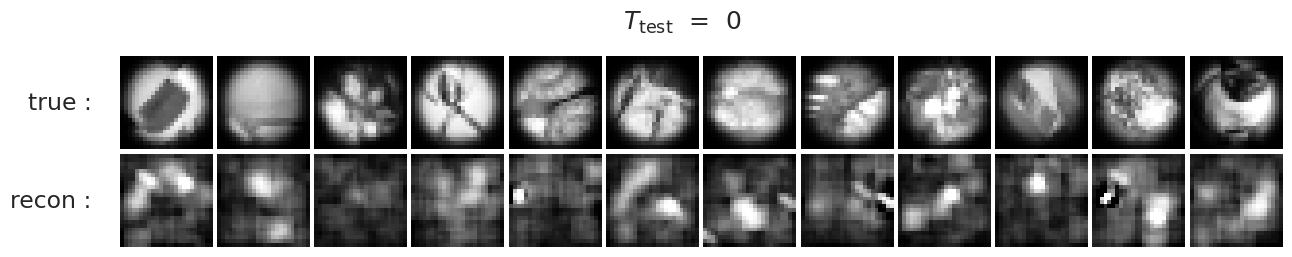

In [50]:
%%time


_ = animate_recons(
    save_file=pjoin(anim_dir, mp4_file_name),
    recon=recon_to_anim,
    true=true_to_anim,
    n_samples=12,
    vmin=0.0,
    vmax=0.75,
    # dry_run=True,
)